###Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest

# Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=y_train.mean(),  # expected failure rate
    random_state=42
)

iso.fit(X_train)


IsolationForest(contamination=np.float64(0.05765), n_estimators=200,
                random_state=42)

In [ ]:
# Isolation Forest gives anomaly scores (lower = more anomalous)
y_scores_iso = -iso.decision_function(X_test)  # flip sign so higher = more failure-like
y_pred_iso = iso.predict(X_test)

# Convert (-1 anomaly, 1 normal) -> (1 failure, 0 no-failure)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Metrics
roc_auc_iso = roc_auc_score(y_test, y_scores_iso)
pr_auc_iso = average_precision_score(y_test, y_scores_iso)

print("Isolation Forest Results:")
print(f"ROC-AUC: {roc_auc_iso:.4f}")
print(f"PR-AUC : {pr_auc_iso:.4f}")


Isolation Forest Results:
ROC-AUC: 0.5491
PR-AUC : 0.0694


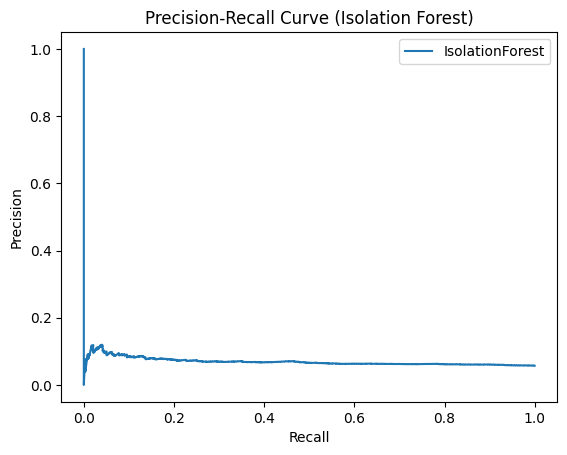

In [ ]:

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores_iso)
plt.plot(recall, precision, label="IsolationForest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Isolation Forest)")
plt.legend()
plt.show()